# 第57篇 | XGBoost：集成学习的王者，Kaggle竞赛大杀器

> 这是「数据分析从入门到精通」系列的第 57 篇。降维搞定了，这篇来学数据科学竞赛里的"核武器"——XGBoost。它是梯度提升决策树的集大成者，速度快、效果强、调参灵活，是 Kaggle 冠军方案里出现频率最高的算法。

嗨，我是小荷～ 今天学一个数据科学竞赛的"核武器"：**XGBoost**！在机器学习界，XGBoost 是绝对的“武林盟主”，不管是打比赛还是工业界预测，它都拿奖拿到手软。

---

## 一、什么是XGBoost？

**XGBoost** = eXtreme Gradient Boosting（极端梯度提升），是梯度提升决策树 (GBDT) 的工程优化升级版，本质是加法模型 + 决策树集成，核心是分步拟合残差、正则控过拟合，通过算法与工程层面的双重突破，在保持高精度的同时大幅提升了训练速度与泛化能力。

我们可以把它想象成一个“错题本提分大法”，或者一个“精英智囊团联合破案”的过程。

假设你要参加高考。如果让你一个人死记硬背，你可能只能考 60 分。那怎么才能考到 98 分呢？XGBoost 采用了以下“迭代式”的训练方法：

1. 派出一号“菜鸟”教辅老师（第一棵决策树）
   我们先找来一个很普通的老师（弱分类器）。他看了一下所有题目，做了一套粗糙的卷子，考了 60 分。

   重点来了：一号老师下班前，把所有做错的题目、丢分的考点，密密麻麻地抄在了一个“错题本”上（计算残差）。

3. 派出二号教辅老师，专项攻克错题（第二棵决策树）

   二号老师上场了。他不需要从头学起，他的唯一任务就是死盯着一号老师留下的“错题本”。

   只要是一号老师做错的题，二号老师就拼命钻研，试图把分补回来。

   二号老师发力后，把整体分数从 60 分提升到了 75 分。

   同样，二号老师把剩下依然做错的题，更新到了“错题本”上。

3. 三号、四号、千万号教辅老师接力（循环迭代）

   三号老师上场，继续盯着二号留下的错题本……

   以此类推，后面上场的每一位老师，都不去重复前面人的工作，而是专门给前面的人“擦屁股”补漏。

5. 最终考试：智囊团联合表决

   高考当天，把这 100 位老师请到现场。面对一道新题，一号老师说：“我觉得选 A（贡献 60 分的权重）”，二号老师根据错题经验说：“不对，一号在这里容易犯错，应该修正选 B（贡献 15 分的权重）”……

   把所有老师的修正意见加在一起，就是最终的完美答案。

**XGBoost 凭什么叫“极致（eXtreme）”**

上面这种“看错题本”的思路叫 Gradient Boosting（梯度提升）。而 XGBoost 之所以有个 X（极致），是因为它把这个过程优化到了变态的地步：

1. 聪明的“预判”：不仅看错了哪些，还看掌握的程度（二阶导数）
   普通的算法只看一号老师错了几分都是哪些题（一阶导数）。XGBoost 更聪明，它不仅看错了几分，还通过高能数学（二阶泰勒展开）精确计算出：这道错题难不难？如果改正它，性价比高不高？ 这让它找错题规律时比别人准得多。
   - 二阶导数（我们一般记为 hᵢ ）大，就代表这个数据点处于敏感、不稳定的区域（高难度怪题）；
   - 二阶导数小，就代表区域平缓、规律明显（低难度粗心题）

2. 防猝死机制：不让老师钻牛角尖（正则化 Penalty）
   如果一个老师为了死磕一道怪题，把整本书都背下来，这就叫“过拟合”（死记硬背，换道题就不会了）。XGBoost 内置了严格的惩罚机制：如果一棵树分得太细、长得太高，算法就会直接“修剪”它，逼着老师们只记通用规律，不记偏题怪题。

3. 速度狂魔：并行的“千手观音”（并行计算）
   传统的算法只能等一号老师写完错题本，二号老师才能看。XGBoost 在结构上做了天才的设计，它在找“怎么切分数据最快”时，可以让电脑的多个 CPU 核心同时开工、并行搜索，速度比传统算法快了几十倍。

**核心优势**：
- 🚀 **速度快**：支持并行计算，比传统GBDT快10倍+
- 🎯 **精度高**：内置正则化，防止过拟合
- 🔧 **功能强**：支持自定义损失函数、缺失值处理
- 📊 **可扩展**：处理大规模数据，分布式训练


In [ ]:
# 卸载所有版本
!pip uninstall -y xgboost
# 重装最新版
!pip install xgboost==3.2.0

In [2]:
import xgboost
print(xgboost.__version__)

3.2.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("XGBoost 集成学习")
print("=" * 60)

# 生成分类数据
np.random.seed(42)
X, y = make_classification(n_samples=2000,  # 总样本数2000条
                           n_features=20,  # 总特征数20个
                           n_informative=15, # 有效特征15个（对分类有作用）
                           n_redundant=5,  # 冗余特征5个（由有效特征衍生，无实际作用）
                           n_classes=2,  # 二分类任务
                           weights=[0.7, 0.3], # 样本不均衡，两类占比分别为70%、30%
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")
print(f"类别分布: {np.bincount(y)}")


XGBoost 集成学习
训练集: (1600, 20)
测试集: (400, 20)
类别分布: [1397  603]


---

## 二、XGBoost vs 其他集成算法

下面我们批量训练随机森林、传统梯度提升、XGBoost三种集成分类模型，对比它们在训练集、测试集上的准确率，并通过准确率差值判断过拟合程度。

In [12]:
# 从sklearn集成学习模块导入随机森林、梯度提升分类器
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# 导入准确率评价指标，用于计算模型预测精度
from sklearn.metrics import accuracy_score
# 导入XGBoost模型库
import xgboost as xgb
# 导入pandas，常用于数据读取、处理与结构化展示
import pandas as pd

# 模拟数据集占位注释，实际使用时替换为自己划分好的训练/测试集
# X_train, X_test, y_train, y_test = ...

# 打印标题：算法性能对比
print("\n算法性能对比:")
# 打印60个等号作为分隔线，美化输出格式
print("=" * 60)

# 字典统一存放三个对比模型，键为模型名称，值为模型实例
models = {
    # 随机森林分类器：树数量100，固定随机种子保证结果可复现
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    # 传统梯度提升分类器：树数量100，固定随机种子
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    # XGBoost分类器：树数量100、固定随机种子，指定评估指标为logloss（对数损失）
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# 定义空列表，用于存储每个模型的评估结果，后续可转为DataFrame分析
results = []
# 打印表格表头，设置每列左对齐+固定宽度，规整输出样式
print(f"{'模型':<18} {'训练准确率':<12} {'测试准确率':<12} {'差距':<12}")

# 遍历模型字典，逐个训练、评估每个模型
for name, model in models.items():
    # 使用训练集训练模型
    model.fit(X_train, y_train)
    # 模型在训练集上做预测
    train_pred = model.predict(X_train)
    # 模型在测试集上做预测
    test_pred = model.predict(X_test)

    # 计算训练集准确率
    train_acc = accuracy_score(y_train, train_pred)
    # 计算测试集准确率（泛化能力核心指标）
    test_acc = accuracy_score(y_test, test_pred)
    # 计算训练、测试准确率差值，用来判断过拟合程度
    diff = train_acc - test_acc

    # 将当前模型结果以字典形式存入结果列表
    results.append({
        '模型': name,
        '训练准确率': train_acc,
        '测试准确率': test_acc,
        '差距': diff
    })

    # 格式化打印单条模型结果：左对齐、固定列宽、数值保留4位小数
    print(f"{name:<20} {train_acc:<15.4f} {test_acc:<15.4f} {diff:<15.4f}")


算法性能对比:
模型                 训练准确率        测试准确率        差距          
Random Forest        1.0000          0.9125          0.0875         
Gradient Boosting    0.9769          0.8975          0.0794         
XGBoost              1.0000          0.9200          0.0800         


- 从数据来看，随机森林（Random Forest）在训练集上达到了完美的 1.0000 准确率，但在测试集上仅为 0.9125，产生了高达 0.0875 的泛化差距，训练集表现极佳但测试集表现下降（过拟合）。
- XGBoost 同样在训练集上达到了 1.0000，但其测试准确率（0.9200）是三者中最高的，且泛化差距（0.0800）控制得比随机森林更好。XGBoost内置的正则化机制使其在追求高精度的同时，能有效惩罚叶节点权重，从而更好地控制模型复杂度，防止过拟合。
- 传统的梯度提升模型（Gradient Boosting）展现出了最为保守的特性。它的训练准确率（0.9769）没有达到完美，但测试准确率（0.8975）与训练集的差距最小（0.0794）。它在拟合训练数据时相对“克制”，因此没有出现过拟合，但也因为模型复杂度受限，导致其捕捉数据深层非线性规律的能力稍弱，整体准确率略逊于 XGBoost。

XGBoost 是结构化数据的首选：在本次对比中，XGBoost 凭借正则化和工程优化，实现了最高测试准确率，印证了其在表格数据建模中的统治地位。

---

## 三、XGBoost核心原理

(枯燥预警，请保持清醒😉😉)

XGBoost 的核心是一句话：它是一个**基于残差优化的**、高效且**加入了正则化惩罚**的梯度提升树（GBDT）架构。

在谈XGBoost我们先返璞归真，回到它的起点：Gradient Boosting（梯度提升算法）。

**梯度提升回顾**：

**1. 核心工作流**
    1. 训练第一棵树，拟合数据
    2. 串行纠错：计算残差（预测与真实的差距），在每一轮迭代中，它利用损失函数（Loss Function）的一阶导数（即负梯度 $-\frac{\partial L}{\partial \hat{y}}$）来近似代替残差，从而训练下一棵树。它只知道当前误差往哪个方向走（一阶梯度）。
    3. 接力比赛：训练下一棵树拟合残差
    4. 累加所有树的预测
    
**2. 弱分类器：为什么偏爱基决策树（CART）？**
Gradient Boosting 理论上可以使用任何弱分类器（比如线性回归、浅层神经网络），但在实际应用中，它几乎 99% 的情况下都绑定 CART 决策树（Classification and Regression Trees）。

原因在于决策树具备以下天然的数学和工程优势：
- 非线性拟合能力： 哪怕是很浅的树（比如深度为 3 到 5），通过多层阶梯式的切分，也能完美勾勒出极其复杂的非线性边界。
- 不惧怕特征尺度： 树模型不需要做归一化或标准化。身高 180cm 和收入 1,000,000 在树的节点分裂眼里只是一个切分阈值，不会因为尺度悬殊而导致梯度爆炸。
- 天生擅长处理特征的交叉： 树从根节点一路劈下来，路径本身（例如：若年龄 > 30 且 收入 > 10万）就是天然的特征交叉组合。

**3. Gradient Boosting局限性**
虽然奠定了武林宗师的地位，但经典的 Gradient Boosting 也有明显的时代局限性（这也正是后来 XGBoost、LightGBM 乃至 CatBoost 诞生的动力）：

- 容易过拟合（Overfitting）： 传统的 Gradient Boosting 如果树加得太多，或者树长得太深，它会极其偏执地去拟合每一个离群点（Outlier），导致在训练集上表现完美，在测试集上直接崩溃。
- 速度是硬伤： 因为它是纯串行的，下一棵树必须等前一棵树算完负梯度、排好序、找完分裂点才能开工。在大数据时代，传统的 GBDT 经常跑到内存溢出或慢到让人崩溃。
- 无法原生处理缺失值： 遇到缺失数据，传统的 Gradient Boosting 必须依赖人工提前进行填充，否则算法在分裂节点时不知道该把缺失值往哪条分叉路口赶。

**XGBoost核心原理**

开头我们举了个例子解释XGBoost，现在更深入地来理解它的核心原理。

**1. 加法模型与梯度提升思想**
   
   XGBoost的核心思想是集成学习中的Boosting技术。它通过逐步构建一系列弱学习器（通常是CART回归树），并将它们的预测结果进行加权求和来构建一个强学习器。在每一轮迭代中，新生成的树旨在拟合前一轮模型预测的残差（误差），从而不断减小模型的损失。

**2. 损失函数的二阶泰勒展开**
   
   传统的 GBDT 在优化损失函数时，只用到了一阶导数（梯度）。而 XGBoost 之所以被称为“Extreme（极致）”，是因为它在目标函数优化上引入了二阶泰勒展开。假设我们在训练第 $t$ 棵树，我们的目标函数（损失函数 + 正则项）可以写成：$$Obj^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$XGBoost 对其在 $\hat{y}_i^{(t-1)}$ 处进行了二阶泰勒展开：$$Obj^{(t)} \approx \sum_{i=1}^{n} [l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \Omega(f_t)$$其中：$g_i$ 是损失函数的一阶导数（Gradient，代表方向）$h_i$ 是损失函数的二阶导数（Hessian，代表加速度/曲率）为什么要费尽心思引入二阶导数 $h_i$？更高的精度： 一阶导数只告诉我们往哪走，二阶导数告诉我们走多快。它让目标函数的逼近更加精准。统一的框架： 只要你的损失函数是二阶可导的（不论是平方损失、逻辑回归的对数损失、还是自定义损失），都可以直接计算出 $g_i$ 和 $h_i$ 带入架构中，极大地增强了算法的通用性。

**3. 目标函数的显式正则化**
   
   XGBoost 在目标函数中直接加入了结构树的复杂度惩罚项（正则化），这是它相比于传统 GBDT 的巨大优势：$$\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$$\gamma T$：$T$ 是叶子节点的个数。叶子越多，惩罚越大（防止树长得太深、太复杂）。$\frac{1}{2}\lambda \sum w_j^2$：$w_j$ 是叶子节点的分数（权重）。这本质上是 L2 正则化（Ridge 惩罚），防止某个叶子节点的分数过大，导致模型对局部样本产生剧烈敏感。有了这套防御机制，XGBoost 在训练时会自动平衡“拟合精度”与“模型简单度”，天然具备极强的抗过拟合能力。

**4. 工程级的高效实现**
   
   在实际建树时，最耗时的操作是寻找每一个特征的最佳分裂点（Split Finding）。

   **精确贪心算法（Exact Greedy Algorithm）**
   把所有特征的取值进行排序，然后遍历所有可能的切分点，计算切分后的增益（Gain）。选择增益最大的那个点进行分裂。
    - 痛点： 当数据量巨大、内存装不下时，这种针对所有特征值进行全局排序的做法会慢到令人窒息。
    
   **近似算法与直方图优化（Approximate Algorithm）**
    为了解决这个工程瓶颈，XGBoost 引入了分位数（Quantiles）近似算法。
    它不再遍历每一个具体的数值，而是根据特征分布的百分位数（例如把数据分成 100 个桶/直方图），只在桶的边界上寻找最佳分裂点。这把计算复杂度降低了几个数量级，也是它能处理海量工业级数据的核心原因。

**XGBoost的改进**：

Gradient Boosting 就像是汽车刚被发明时的原型车，核心动力机制（通过拟合负梯度来纠错）已经跑通了；
而 XGBoost 则是将这辆原型车改装成了一级方程式赛车（F1），在动力、工程结构、防御过拟合以及速度上都做到了极致。

XGBoost的改进：
- **二阶泰勒展开**：更精确的梯度信息
- **正则化**：目标函数内嵌叶子数量与权重的正则惩罚，控制模型复杂度，防止过拟合
- **并行计算**：特征级别的并行
- **缺失值处理**：自动学习分裂方向，脏数据容忍度极高，不需要手动填补
- **树剪枝**：自底向上剪枝，更高效


---

## 四、XGBoost基础使用

上面的理论看得很迷糊？先上手跑通，再慢慢理解：


In [18]:
print("\nXGBoost基础使用:")

# 基础模型
xgb_model = xgb.XGBClassifier(
    n_estimators=100,  # 树的数量
    max_depth=3,  # 树的最大深度
    learning_rate=0.1,  # 学习率
    subsample=0.8,  # 样本采样比例
    colsample_bytree=0.8,  # 特征采样比例
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# 预测
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"测试准确率: {accuracy_score(y_test, y_pred):.4f}")
print(f"\n分类报告:")
print(classification_report(y_test, y_pred))



XGBoost基础使用:
测试准确率: 0.8850

分类报告:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       279
           1       0.84      0.76      0.80       121

    accuracy                           0.89       400
   macro avg       0.87      0.85      0.86       400
weighted avg       0.88      0.89      0.88       400



---

## 五、XGBoost关键参数详解

XGBoost 的强大性能在很大程度上取决于其超参数的合理配置。

XGBoost 的参数通常分为三大类：通用参数（General Parameters）、提升器参数（Booster Parameters）和学习目标参数（Learning Task Parameters）。

**通用参数（General Parameters）**

这组参数负责控制 XGBoost 的宏观运行环境，比如选择什么样的底层驱动、用多少个 CPU 核心来跑并行计算。通常在模型初始化后就不再变动。
  - booster (默认: gbtree)
    选择使用哪种弱学习器。gbtree（基于树的模型，最常用）、gblinear（线性模型）或 dart（加入了 Dropout 机制的树模型）。
  - n_jobs / nthread (默认: 最多可用核心数)
    并行计算时使用的 CPU 线程数。在本地调参时通常设为 -1，表示榨干 CPU 的所有核心来加速特征并行的特征块（Block）计算。
  - verbosity (默认: 1)
    打印日志的详细程度。0 表示沉默（不打印），1 表示警告（Warning），2 表示信息（Info），3 表示调试（Debug）。

**提升器参数（Booster Parameters）**

**结构控制：控制树的复杂度（防止过拟合）**
  - max_depth (默认: 6)
    树的最大深度。增加该值会使模型更复杂，能捕获特征间更复杂的交互，但也增加了过拟合的风险。典型范围通常在 3-10 之间。
  - min_child_weight (默认: 1)
    子节点进一步划分所需的最小实例权重（Hessian）总和。该值越大，算法越保守，倾向于生成更简单的树。对于不平衡数据，提高此值通常有帮助。
  - gamma (min_split_loss)
    在叶子节点上进行进一步分区所需的最小损失减少量。它作为一个阈值来决定叶节点是否应该继续分裂，值越大，模型越保守，常用于防止过拟合。

**速度与节奏：控制步长与树的数量**
  - n_estimators (默认: 100)
    提升的轮数（即生成的决策树数量）。它与学习率呈反比关系，通常结合“早停（Early Stopping）”技术使用，在验证集指标不再提升时自动停止训练，以节省资源并防止过拟合。
  - learning_rate / eta (默认: 0.3)
    控制每棵树对最终预测的贡献权重（步长缩减）。较低的学习率能使学习过程更稳健，有效防止过拟合，但通常需要配合更多的树数量（n_estimators）

**随机性引入：抗噪与样本/特征采样**
  - subsample (默认: 1)
    对训练样本的采样比例（行采样）。例如设为 0.8 表示每棵树仅使用 80% 的随机样本来训练。
  - colsample_bytree (默认: 1)
    构建子树时对特征的采样比例（列采样）。例如设为 0.8 表示每棵树仅使用 80% 的可用特征
  - colsample_bylevel
    在寻找最佳划分点时对特征的采样比例，进一步增加随机性。

**正则化参数**
  - reg_lambda / lambda (默认: 1)
    L2 正则化系数。惩罚叶子节点的权重，值越大模型越简单，通常比 L1 更常用。
  - reg_alpha / alpha (默认: 0)
    L1 正则化系数。能够将不重要特征的权重缩小到 0，实现特征选择，使模型更简单。

**学习目标参数（Learning Task Parameters）**

这组参数决定了模型要解决什么问题。它们负责指定任务的方向、如何衡量对错（损失函数）以及如何评估最终的表现。
  - objective (默认: reg:squarederror)
    指定要优化的损失函数。常用值：
       - binary:logistic：二分类任务，输出概率。
       - multi:softprob：多分类任务，输出每个类别的概率。
       - reg:squarederror：回归任务。
  - eval_metric (默认: 根据 objective 自动选择)
    验证集上的评估指标，决定了早停（Early Stopping）何时被触发。常见核心值： logloss（二分类对数损失）、auc（ROC曲线曲线下面积）、merror（多分类错误率）、rmse（回归均方根误差）。
  - scale_pos_weight (默认: 1)
    正负样本的权重平衡系数。处理严重类别不平衡（如欺诈检测、罕见病筛查）的核武器。
    
|参数分类|参数名|取值说明 \& 作用|默认值|建议取值范围|
|---|---|---|---|---|
|**通用参数**|booster|基学习器类型：<br>• `gbtree`：树模型（默认）<br>• `gblinear`：线性模型<br>• `dart`：Dropout 增强树|gbtree|根据任务选择|
|**提升器参数-树结构参数**|max\_depth|单棵决策树最大深度，控制模型复杂度；数值越大模型越复杂，易过拟合|6|3 \~ 10|
||min\_child\_weight|叶子节点最小样本权重和；数值越大模型越保守，抑制过拟合|1|视数据集调整|
||gamma|节点分裂所需的最小损失下降值；仅当分裂带来足够增益时才分裂，越大越保守|0|0 \~ 5|
|**提升器参数-步长与数量**|learning_rate / eta|步长/收缩率。用来压缩每棵新树的贡献，低步长配合高迭代次数能让模型更稳健。|0.3|0.01~ 0.3|
||n_estimators|要建立的弱学习器（树）的总数量|100|100~ 10000+|
|**提升器参数-正则化参数**|reg\_alpha|L1 正则项系数，增大可提升特征稀疏性、减少冗余特征|0|0 \~ 1|
||reg\_lambda|L2 正则项系数，增大可有效防止过拟合|1|1 \~ 10|
|**提升器参数-采样参数**|subsample|每棵树训练时的样本采样比例，引入随机性，防过拟合、加速训练|1|0\.5 \~ 1\.0|
||colsample\_bytree|每棵树训练时的特征采样比例，增加随机性，降低过拟合|1|0\.5 \~ 1\.0|
||colsample\_bylevel|树每一层节点的特征采样比例|1|0\.5 \~ 1\.0|
||colsample\_bynode|单个树节点的特征采样比例|1|0\.5 \~ 1\.0|
|**学习目标参数**|objective|定义模型的损失函数（最小化目标）<br>• `reg:squarederror`：标准的回归任务（均方误差）<br>• `binary:logistic`：二分类任务<br>• `multi:softprob`：多分类任务|reg:squarederror|根据任务选择|
||eval_metric|决策树总数量，和学习率呈权衡关系：学习率越小，通常需要更多树 <br>• `logloss`：二分类对数损失<br>• `auc`：ROC曲线曲线下面积<br>• `merror`：多分类错误率 <br>• `rmse`：回归均方根误差|根据 objective 自动选择|logloss、auc、merror、rmse|
||scale_pos_weight|决策树总数量，和学习率呈权衡关系：学习率越小，通常需要更多树|1|理论上是 $(0, +\infty)$|

---

## 六、特征重要性

XGBoost 提供了多种评估特征重要性的指标。我们来看下核心的5种：
- weight（权重/频次）：特征被用于分裂节点的总次数。
- gain（平均增益）：特征在分裂时带来的平均信息增益（衡量特征对目标变量的预测能力）。
- cover（平均覆盖度）：特征分裂时覆盖的平均样本数。
- total_gain（总增益）：特征带来的所有信息增益的总和。
- total_cover（总覆盖度）：特征分裂时覆盖的样本总数。

下面我们对前面训练好的 XGBoost 模型进行全面的特征重要性（Feature Importance）分析与可视化。
- 前 5 个子图分别使用 barh（水平条形图）展示了上述 5 种指标下的 Top 10 重要特征。
- 在第 6 个子图中，代码调用了 XGBoost 官方的 xgb.plot_importance() 函数，作为基准（Baseline）展示。


特征重要性分析:


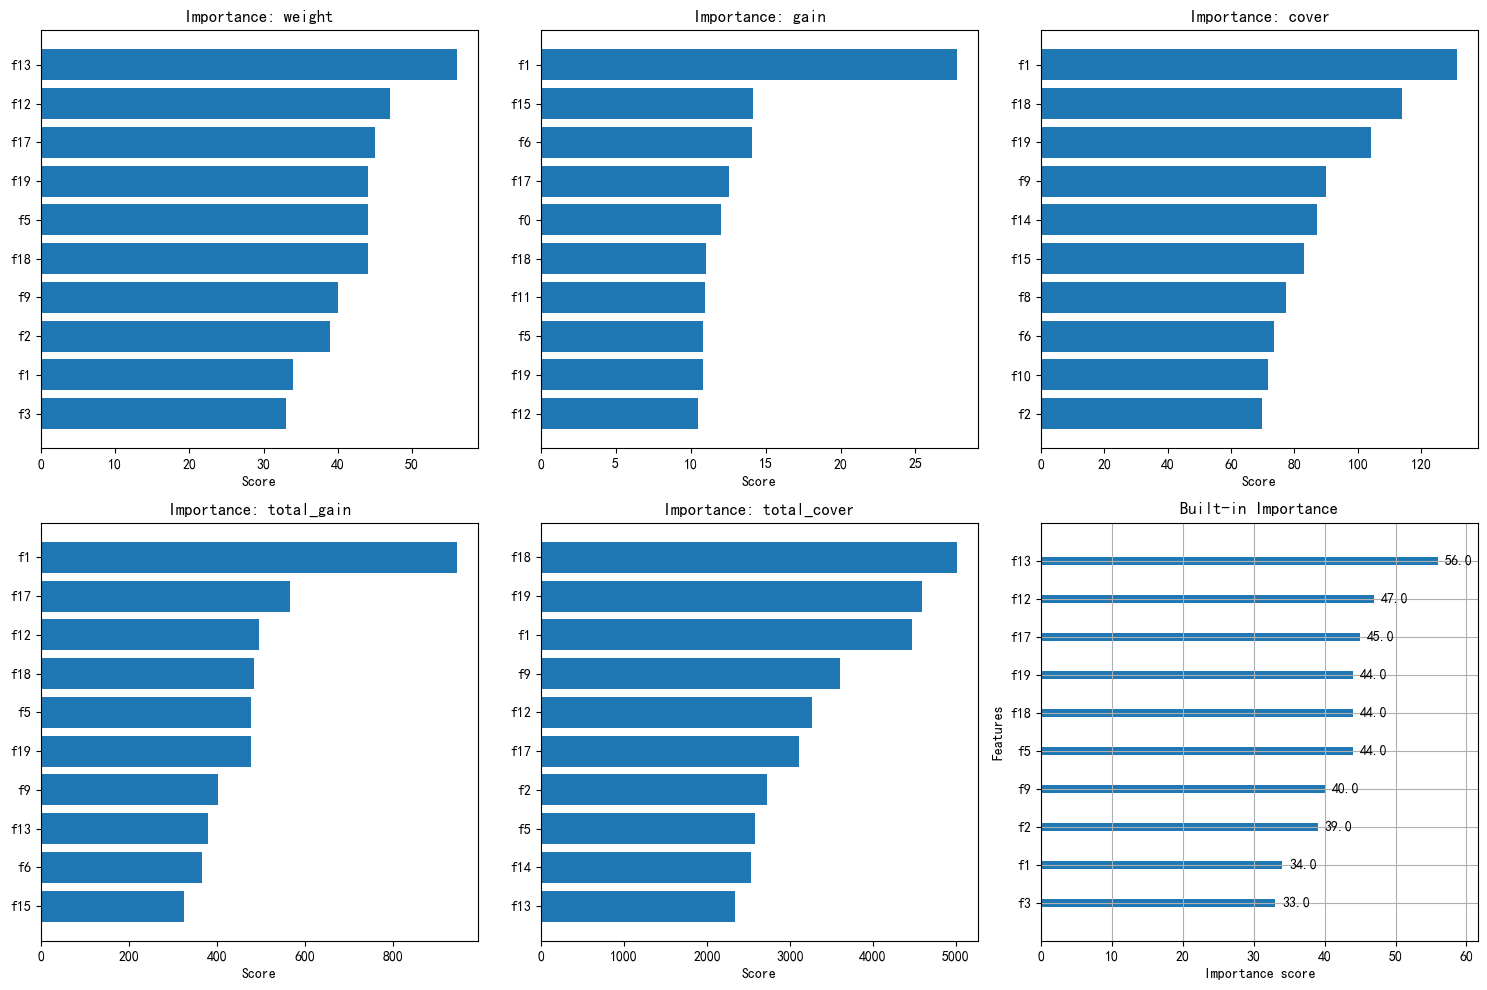

In [19]:
# 打印标题，换行后输出文本
print("\n特征重要性分析:")

# 定义XGBoost支持的5种特征重要性计算类型
importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

# 创建 2行3列 的画布，画布尺寸(宽15, 高10)，用于绘制多张子图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# 将二维数组的子图轴对象展平为一维列表，方便按索引遍历调用
axes = axes.flatten()

# 遍历所有特征重要性类型，逐个绘制对应柱状图
for idx, importance_type in enumerate(importance_types):
    # 取出当前循环对应的子图坐标轴
    ax = axes[idx]

    # 获取模型 booster 对象，并按指定类型计算特征重要性得分
    # 返回字典：key=特征名，value=对应重要性分数
    importance = xgb_model.get_booster().get_score(importance_type=importance_type)

    # 将特征重要性字典转为DataFrame表格，方便排序与绘图
    importance_df = pd.DataFrame({
        'feature': list(importance.keys()),  # 特征名称
        'score': list(importance.values())   # 对应重要性分数
    }).sort_values('score', ascending=True).tail(10)  # 按分数升序排序，取分数最高的前10个特征

    # 绘制横向柱状图：y轴为特征名，x轴为分数
    ax.barh(importance_df['feature'], importance_df['score'])
    # 设置当前子图标题，标注重要性类型
    ax.set_title(f'Importance: {importance_type}')
    # 设置x轴标签
    ax.set_xlabel('Score')

# 使用第6个子图（索引5），绘制XGBoost内置特征重要性图
ax = axes[5]
# 调用xgboost内置绘图方法，只展示Top10特征，绑定到指定子图
xgb.plot_importance(xgb_model, ax=ax, max_num_features=10)
# 设置该子图标题
ax.set_title('Built-in Importance')

# 自动调整子图间距、边距，避免标签重叠遮挡
plt.tight_layout()
# 展示所有绘图结果
plt.show()

---

## 七、早停与交叉验证

训练不是越久越好，早停（Early Stopping）与交叉验证（Cross-Validation, CV）是解决过拟合问题、寻找最优模型复杂度的“黄金搭档”。

- 早停（Early Stopping）：
   - 这是一种防止模型过拟合的训练控制策略。其核心思想是在训练过程中持续监控模型在独立验证集上的表现。一旦连续多轮（由 early_stopping_rounds 参数控制）验证集的性能指标不再提升，算法就会自动停止训练。这不仅能节省计算资源和时间，还能精准捕捉到模型泛化能力最好的“拐点”。
   - early_stopping_rounds 属于训练控制与优化参数。它不属于决定模型结构的提升器参数（Booster Parameters），也不属于决定业务对错的学习目标参数（Learning Task Parameters），而是作为回调机制（Callback）或训练配置存在，用来动态控制训练迭代的终止时机，防止模型过拟合并节省算力。
- 交叉验证（Cross-Validation）：传统的早停往往依赖单一固定的验证集，这可能导致评估结果具有偶然性。交叉验证通过将数据集划分为多个（如5折）子集，轮流作为验证集，从而提供更稳健、更具泛化性的性能衡量标准。

将早停与交叉验证结合使用，可以自动寻找最优的提升轮数（树的数量），且无需过度依赖单次数据划分。XGBoost 提供了内置的高效函数 xgb.cv() 来一步完成这一过程。

下面演示两大核心能力：**模型早停训练 + XGBoost 原生 5 折交叉验证**，用于防止模型过拟合、评估模型泛化能力。

In [27]:
# 导入新版早停回调（3.x 必需）
from xgboost.callback import EarlyStopping

# 打印标题，演示早停机制相关内容
print("\n早停机制 (Early Stopping):")

# 从原有训练集中再划分出一部分作为验证集，专门用于早停判断
# test_size=0.2：验证集占原训练集的20%
# stratify=y_train：分层抽样，保证训练子集、验证集类别分布和原训练集一致
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# 定义早停回调：连续10轮指标不提升则停止
early_stop_cb = EarlyStopping(rounds=10)

# 初始化XGBoost分类模型
xgb_model_es = xgb.XGBClassifier(
    n_estimators=1000,        # 预设最大树数量，设较大值，依靠早停提前终止训练
    max_depth=5,              # 单棵树最大深度
    learning_rate=0.1,        # 学习率
    subsample=0.8,            # 每棵树随机采样80%样本训练
    colsample_bytree=0.8,     # 每棵树随机采样80%特征训练
    random_state=42,          # 固定随机种子，结果可复现
    eval_metric='logloss',     # 训练过程使用对数损失作为评估指标
    callbacks=[early_stop_cb],
    n_jobs=-1                  # 使用本机所有CPU核心并行运算，加速训练
)

# 模型训练
# eval_set：传入验证集，训练时持续监控该数据集指标
# verbose=False：关闭训练过程日志输出
xgb_model_es.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    # callbacks=[early_stop],
    verbose=False
)

# 输出早停得到的最优迭代轮数
print(f"最优迭代次数: {xgb_model_es.best_iteration}")
# 输出最优迭代轮对应的验证集得分
print(f"最优得分: {xgb_model_es.best_score:.4f}")

# 使用训练好的模型在测试集上做预测
y_pred_es = xgb_model_es.predict(X_test)
# 计算并打印测试集准确率，保留4位小数
print(f"测试准确率: {accuracy_score(y_test, y_pred_es):.4f}")

# 打印标题，演示XGBoost原生交叉验证功能
print("\nXGBoost交叉验证:")

# 转换为XGBoost专属DMatrix数据格式，运算效率更高
dtrain = xgb.DMatrix(X_train, label=y_train)

# 定义模型超参数字典（原生API参数）
params = {
    'max_depth': 5,                # 树最大深度
    'learning_rate': 0.1,          # 学习率
    'subsample': 0.8,              # 样本采样比例
    'colsample_bytree': 0.8,       # 特征采样比例
    'objective': 'binary:logistic',# 目标函数：二分类逻辑回归
    'eval_metric': 'logloss'       # 评估指标：对数损失
}

# 【新版改动】cv 同样改用 callbacks 传早停，不再直接写 early_stopping_rounds
cv_early_stop = EarlyStopping(rounds=10)

# 执行XGBoost内置K折交叉验证
# xgb.cv 是 XGB 原生交叉验证接口，相比 sklearn 交叉验证，对 XGB 模型适配更好、速度更快。
cv_results = xgb.cv(
    params,                # 模型参数
    dtrain,                # 训练数据（DMatrix格式）
    num_boost_round=100,   # 最大迭代轮数（最大树数量）
    nfold=5,               # 5折交叉验证
    metrics=['logloss', 'auc'],# 同时监控对数损失、AUC两个指标
    seed=42,               # 固定随机种子
    callbacks=[cv_early_stop]  # 传入早停回调
)

# 打印交叉验证最终一轮的结果
print(f"交叉验证结果（最后一轮）:")
print(cv_results.tail(1))


早停机制 (Early Stopping):
最优迭代次数: 172
最优得分: 0.1934
测试准确率: 0.9200

XGBoost交叉验证:
交叉验证结果（最后一轮）:
    train-logloss-mean  train-logloss-std  train-auc-mean  train-auc-std  \
99            0.043505            0.00255        0.999999       0.000001   

    test-logloss-mean  test-logloss-std  test-auc-mean  test-auc-std  
99           0.196778          0.027232       0.971773      0.008494  


**早停机制的成果：精准锁定最优复杂度**
- 最优迭代次数 (172)：模型在训练到第 172 棵树时，验证集的性能达到了瓶颈并停止了训练。这说明 172 棵树就是当前参数配置下，模型泛化能力最好的“黄金节点”。继续训练不仅浪费算力，还会导致过拟合。
- 最优得分 (0.1934)：这是早停时监控的验证集指标（Logloss 损失值）。该值越低，说明模型对验证集数据的预测概率越贴近真实标签。

**交叉验证的评估：模型极其稳定且强大**

交叉验证的结果（第 99 轮的数据）揭示了模型在多个数据折上的综合表现：
- 极高的训练集拟合度：train-auc-mean 高达 0.999999，且标准差几乎为 0。这说明模型在训练集上几乎做到了完美分类，且每一折的表现都高度一致。
- 优秀的测试集泛化能力：test-auc-mean 达到了 0.971773，且标准差仅为 0.008494。极高的 AUC 分数证明模型具有极强的区分正负样本的能力；而极小的标准差则说明模型非常稳定，没有因为数据划分的变化而产生剧烈波动。
- Logloss 表现：test-logloss-mean 为 0.196778，进一步印证了模型输出的预测概率具有较高的置信度和准确性。

---

## 八、超参数调优

参数调得好，模型性能上一个台阶。下面我们利用随机搜索（Randomized Search）结合交叉验证，对 XGBoost 模型的关键超参数进行自动化调优，并评估最终模型在测试集上的表现。

**主要步骤：**
1. 定义超参数搜索空间 `param_grid`
2. 执行随机搜索策略 `RandomizedSearchCV `
3. 模型训练与最优参数输出
4.  测试集最终评估 `best_estimator_ `

In [28]:
# 打印标题，开始演示 XGBoost 超参数调优流程
print("\nXGBoost超参数调优:")

# 定义超参数搜索网格：设置待遍历的参数及候选取值
param_grid = {
    'max_depth': [3, 5, 7],          # 树最大深度候选值
    'learning_rate': [0.01, 0.1, 0.3],# 学习率候选值
    'n_estimators': [100, 200],       # 决策树数量候选值
    'subsample': [0.8, 1.0],          # 单棵树样本采样比例候选值
    'colsample_bytree': [0.8, 1.0]    # 单棵树特征采样比例候选值
}

# 遍历参数字典，打印所有待搜索的参数与对应取值
print("参数搜索空间:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# 导入随机搜索工具：相比网格搜索，遍历更少组合，速度更快
from sklearn.model_selection import RandomizedSearchCV

# 初始化基础XGBoost分类器，固定随机种子与评估指标
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 构建随机搜索器
random_search = RandomizedSearchCV(
    xgb_base,               # 待调优的基础模型
    param_grid,             # 超参数搜索空间
    n_iter=20,              # 随机抽取20组参数组合进行试验
    cv=3,                   # 3折交叉验证评估每组参数
    scoring='accuracy',     # 以准确率作为评估指标
    n_jobs=-1,              # 使用全部CPU核心并行运算，加速搜索
    random_state=42,        # 固定随机种子，结果可复现
    verbose=1               # 打印搜索过程日志
)

# 提示信息
print("\n开始随机搜索...")
# 在训练集上执行超参数随机搜索
random_search.fit(X_train, y_train)

# 遍历并打印搜索得到的最优超参数
print(f"\n最优参数:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

# 打印最优参数对应的交叉验证平均得分，保留4位小数
print(f"\n最优交叉验证得分: {random_search.best_score_:.4f}")

# 获取搜索得到的最优模型
best_xgb = random_search.best_estimator_
# 使用最优模型在测试集上做预测
y_pred_best = best_xgb.predict(X_test)
# 计算并输出测试集准确率，保留4位小数
print(f"测试集准确率: {accuracy_score(y_test, y_pred_best):.4f}")


XGBoost超参数调优:
参数搜索空间:
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1, 0.3]
  n_estimators: [100, 200]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]

开始随机搜索...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

最优参数:
  subsample: 0.8
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.3
  colsample_bytree: 1.0

最优交叉验证得分: 0.9250
测试集准确率: 0.9250


这段代码展示了一个标准的机器学习调参工程流水线。通过随机搜索，它能在有限的计算资源下快速探索参数空间，找到兼顾模型精度与泛化能力的最佳配置，避免了人工盲目调参的低效与主观性。

---

## 九、综合实战：乳腺癌检测

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来。以下代码是一个基于 XGBoost 的乳腺癌检测完整实战案例。它展示了从数据加载、预处理、模型构建、早停机制应用，到最终预测评估的标准机器学习工程流水线。

**主要步骤 (提示：仔细看代码和代码注释！)**：
1. 数据加载与分层划分
2. XGBoost 模型初始化与正则化配置
3. 验证集拆分与早停机制 (Early Stopping)
4. 模型训练
5. 多维度预测与业务评估

In [11]:
#  这里演示直接本地读取数据文件
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
# 新版必备：导入早停回调
from xgboost.callback import EarlyStopping

print("综合实战：乳腺癌检测")

# 1. 使用 Pandas 加载本地数据
# WDBC 数据集实际上有 32 列：ID, 诊断结果(M/B), 以及 30 个数值特征
column_names = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=column_names)

# 【关键修正 1】：把标签 'M'(恶性) 和 'B'(良性) 映射为机器学习认识的 1 和 0
data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

# 【关键修正 2】：用 Pandas 的 iloc 提取特征矩阵 X 和标签数组 y
X_cancer = data.iloc[:, 2:].values  # 跳过 id 和 diagnosis，取后 30 列特征
y_cancer = data["diagnosis"].values  # 取标签

# 划分整体训练集、测试集
# test_size=0.2：测试集占总数据20%
# stratify=y_cancer：分层抽样，保证划分后正负样本比例和原数据集一致
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

# 输出特征总数量
print(f"特征数: {X_cancer.shape[1]}")
print(f"特征名前5个: {list(data.columns[2:7])}...")
print(f"类别: ['Benign (0)', 'Malignant (1)']")
print(f"类别分布: {np.bincount(y_cancer)}")

# 2. XGBoost 模型初始化与正则化配置
# 实例化早停回调规则：验证集指标连续20轮无提升，则终止训练
early_stop = EarlyStopping(rounds=20)

# 初始化XGBoost分类模型
xgb_cancer = xgb.XGBClassifier(
    n_estimators=200,        # 最大决策树数量
    max_depth=4,             # 单棵树最大深度，控制模型复杂度
    learning_rate=0.1,       # 学习率，梯度下降步长
    subsample=0.9,           # 每棵树随机采样90%样本训练
    colsample_bytree=0.9,    # 每棵树随机采样90%特征训练
    reg_alpha=0.1,           # L1正则系数，降低过拟合
    reg_lambda=1,            # L2正则系数，降低过拟合
    random_state=42,         # 固定随机种子，保证结果可复现
    eval_metric='logloss',   # 训练过程使用对数损失作为评估指标
    callbacks=[early_stop]
)

# 3. 验证集拆分与早停机制 (Early Stopping)
# 从整体训练集中再拆分出子集和独立验证集，验证集专门用于判断早停
X_train_c_sub, X_val_c, y_train_c_sub, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42, stratify=y_train_c)

# 模型训练
# eval_set：指定监控的验证集
# verbose=False：关闭训练过程日志打印

xgb_cancer.fit(
    X_train_c_sub, y_train_c_sub,
    eval_set=[(X_val_c, y_val_c)],
    # 在 XGBoost 3.x 及较新的版本中，xgb.XGBClassifier（即 Scikit-Learn 兼容接口）在调用 .fit() 方法时，
    # 并不直接支持 callbacks 关键字参数。
    # callbacks=[early_stop],
    verbose=False
)

# 使用训练好的模型在测试集上做类别预测
y_pred_c = xgb_cancer.predict(X_test_c)
# 获取样本为正类的预测概率（取第二列）
y_pred_proba_c = xgb_cancer.predict_proba(X_test_c)[:, 1]

# 打印模型性能标题与分割线
print(f"\n模型性能:")
print("-" * 40)
# 输出早停筛选出的最优迭代轮数
print(f"最优迭代次数: {xgb_cancer.best_iteration}")
# 计算并输出测试集准确率，保留4位小数
print(f"测试准确率: {accuracy_score(y_test_c, y_pred_c):.4f}")

# 输出详细分类评估报告（精确率、召回率、F1值等）
print(f"\n分类报告:")
print(classification_report(y_test_c, y_pred_c, target_names=["Benign", "Malignant"]))

综合实战：乳腺癌检测
特征数: 30
特征名前5个: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']...
类别: ['Benign (0)', 'Malignant (1)']
类别分布: [357 212]

模型性能:
----------------------------------------
最优迭代次数: 70
测试准确率: 0.9649

分类报告:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



这里演示用官方API下载数据文件。

In [36]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
# 新版必备：导入早停回调
from xgboost.callback import EarlyStopping

print("综合实战：乳腺癌检测")

# 1. 数据加载与分层划分
# 加载乳腺癌数据集
data = load_breast_cancer()
# 提取特征矩阵与标签数组
X_cancer, y_cancer = data.data, data.target

# 划分整体训练集、测试集
# test_size=0.2：测试集占总数据20%
# stratify=y_cancer：分层抽样，保证划分后正负样本比例和原数据集一致
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

# 输出特征总数量
print(f"特征数: {X_cancer.shape[1]}")
# 输出前5个特征名称，省略后续特征
print(f"特征名: {data.feature_names[:5]}...")
# 输出类别名称（良性/恶性）
print(f"类别: {data.target_names}")
# 统计并输出两类样本的数量分布
print(f"类别分布: {np.bincount(y_cancer)}")

# 2. XGBoost 模型初始化与正则化配置
# 实例化早停回调规则：验证集指标连续20轮无提升，则终止训练
early_stop = EarlyStopping(rounds=20)

# 初始化XGBoost分类模型
xgb_cancer = xgb.XGBClassifier(
    n_estimators=200,        # 最大决策树数量
    max_depth=4,             # 单棵树最大深度，控制模型复杂度
    learning_rate=0.1,       # 学习率，梯度下降步长
    subsample=0.9,           # 每棵树随机采样90%样本训练
    colsample_bytree=0.9,    # 每棵树随机采样90%特征训练
    reg_alpha=0.1,           # L1正则系数，降低过拟合
    reg_lambda=1,            # L2正则系数，降低过拟合
    random_state=42,         # 固定随机种子，保证结果可复现
    eval_metric='logloss',   # 训练过程使用对数损失作为评估指标
    callbacks=[early_stop]
)

# 3. 验证集拆分与早停机制 (Early Stopping)
# 从整体训练集中再拆分出子集和独立验证集，验证集专门用于判断早停
X_train_c_sub, X_val_c, y_train_c_sub, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42, stratify=y_train_c)

# 模型训练
# eval_set：指定监控的验证集
# verbose=False：关闭训练过程日志打印

xgb_cancer.fit(
    X_train_c_sub, y_train_c_sub,
    eval_set=[(X_val_c, y_val_c)],
    # 在 XGBoost 3.x 及较新的版本中，xgb.XGBClassifier（即 Scikit-Learn 兼容接口）在调用 .fit() 方法时，
    # 并不直接支持 callbacks 关键字参数。
    # callbacks=[early_stop],
    verbose=False
)

# 使用训练好的模型在测试集上做类别预测
y_pred_c = xgb_cancer.predict(X_test_c)
# 获取样本为正类的预测概率（取第二列）
y_pred_proba_c = xgb_cancer.predict_proba(X_test_c)[:, 1]

# 打印模型性能标题与分割线
print(f"\n模型性能:")
print("-" * 40)
# 输出早停筛选出的最优迭代轮数
print(f"最优迭代次数: {xgb_cancer.best_iteration}")
# 计算并输出测试集准确率，保留4位小数
print(f"测试准确率: {accuracy_score(y_test_c, y_pred_c):.4f}")

# 输出详细分类评估报告（精确率、召回率、F1值等）
print(f"\n分类报告:")
print(classification_report(y_test_c, y_pred_c, target_names=data.target_names))

综合实战：乳腺癌检测
特征数: 30
特征名: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...
类别: ['malignant' 'benign']
类别分布: [212 357]

模型性能:
----------------------------------------
最优迭代次数: 67
测试准确率: 0.9474

分类报告:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



模型表现不错，看看 XGBoost 认为哪些特征最重要：


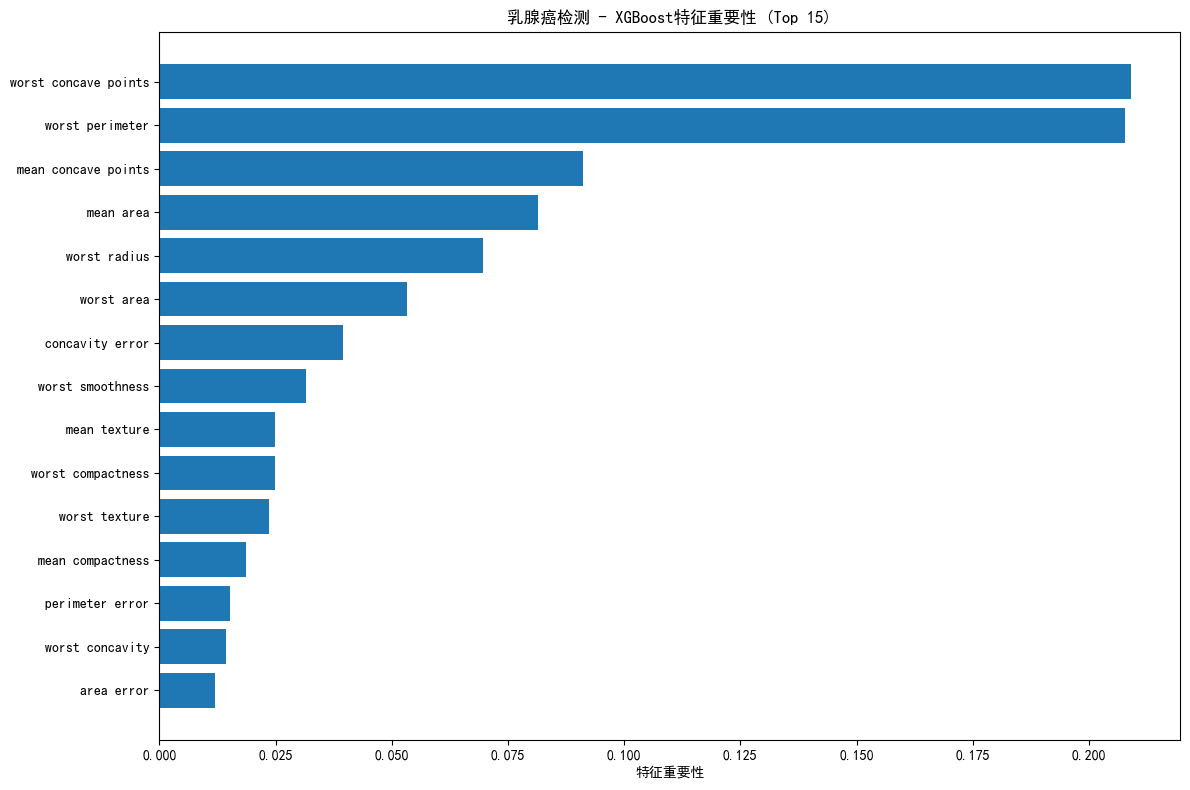


Top 10 重要特征:
             feature  importance
   worst compactness    0.024773
        mean texture    0.024778
    worst smoothness    0.031576
     concavity error    0.039578
          worst area    0.053366
        worst radius    0.069626
           mean area    0.081443
 mean concave points    0.091125
     worst perimeter    0.207645
worst concave points    0.209109


In [7]:
    # 可视化特征重要性
    plt.figure(figsize=(12, 8))
    
    importance_cancer = pd.DataFrame({
        'feature': data.feature_names,
        'importance': xgb_cancer.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)
    
    plt.barh(importance_cancer['feature'], importance_cancer['importance'])
    plt.xlabel('特征重要性')
    plt.title('乳腺癌检测 - XGBoost特征重要性 (Top 15)')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 重要特征:")
    print(importance_cancer.tail(10).to_string(index=False))


---

## 十、XGBoost调参指南

调参是有套路的，来学一学：

第1步：确定学习率和树的数量
  - 固定 learning_rate=0.1, n_estimators=100
  - 用早停找到最优迭代次数
  - 然后降低学习率，增加树的数量

第2步：调整树结构参数
  - max_depth: 通常3-10，从较小值开始
  - min_child_weight: 1-10，控制过拟合
  - gamma: 0-5，分裂阈值

第3步：调整正则化参数
  - reg_lambda: 1-10，L2正则化
  - reg_alpha: 0-1，L1正则化

第4步：调整采样参数
  - subsample: 0.6-1.0
  - colsample_bytree: 0.6-1.0
  - colsample_bylevel: 0.6-1.0

第5步：降低学习率
  - learning_rate: 0.01-0.1
  - 相应增加n_estimators

【经验法则】
- 过拟合 → 降低max_depth，增大min_child_weight/gamma，减小subsample
- 欠拟合 → 增大max_depth，减小min_child_weight，增大n_estimators


---

## 十一、小结

| 参数 | 作用 | 建议范围 |
|------|------|----------|
| **max_depth** | 树深度 | 3-10 |
| **learning_rate** | 学习率 | 0.01-0.3 |
| **n_estimators** | 树数量 | 100-1000 |
| **subsample** | 样本采样 | 0.6-1.0 |
| **colsample_bytree** | 特征采样 | 0.6-1.0 |
| **reg_lambda** | L2正则化 | 1-10 |
| **reg_alpha** | L1正则化 | 0-1 |

**XGBoost vs LightGBM vs CatBoost**：

| 特性 | XGBoost | LightGBM | CatBoost |
|------|---------|----------|----------|
| 速度 | 快 | 更快 | 快 |
| 精度 | 高 | 高 | 高 |
| 类别特征 | 需编码 | 需编码 | 原生支持 |
| 缺失值 | 自动处理 | 自动处理 | 自动处理 |
| GPU支持 | 是 | 是 | 是 |

---

## 十二、课后练习

1. 用XGBoost完成一个回归任务（如房价预测）
2. 对比不同max_depth对模型性能的影响
3. 尝试用网格搜索精细调优XGBoost参数
4. 用XGBoost的特征重要性进行特征选择

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 58 篇：LightGBM — 更快更强的梯度提升**
>
> 下篇学 LightGBM——比 XGBoost 更快的梯度提升框架，使用直方图算法和叶子优先生长策略，大规模数据下的首选。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*
